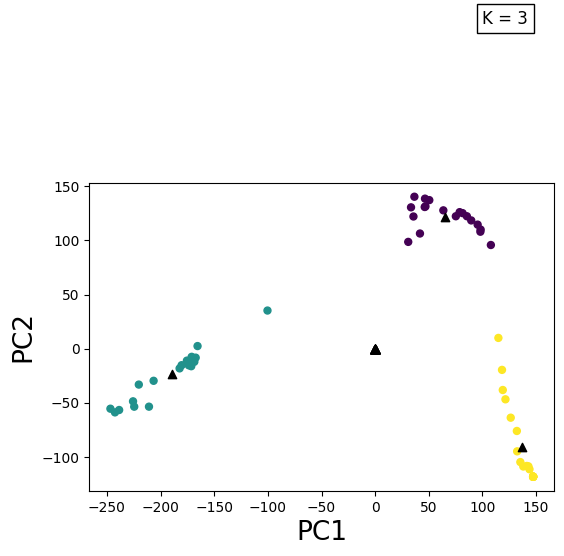

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

stat = pd.read_csv('kmeans_results.csv')
df = pd.DataFrame(stat)

plt.figure(figsize=(6,4))
plt.scatter(df['k3, x'], df['k3, y'], c = df['k3, pred'], s = 25)
plt.scatter(df['k3, centx'], df['k3, centy'], c = 'black', marker = '^' )
plt.text(100, 300, "K = 3", fontsize=12, bbox=dict(facecolor='white'))
plt.xlabel('PC1', fontdict = {'fontsize' : 19})
plt.ylabel('PC2',  fontdict = {'fontsize' : 19})

plt.savefig('PC1-PC2-K3_graph.png')
plt.show()

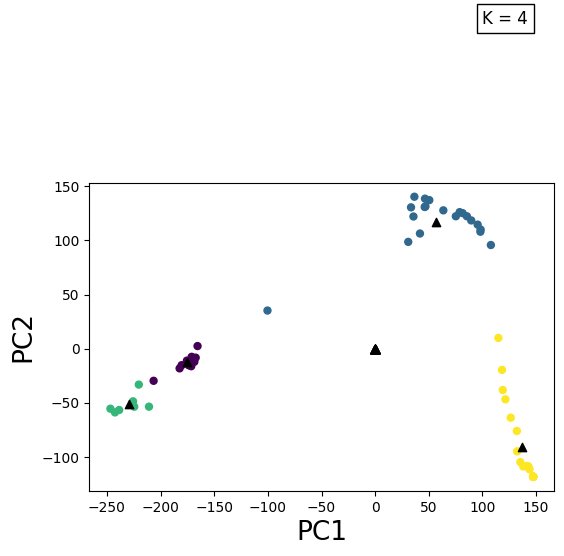

In [10]:
plt.figure(figsize=(6,4))
plt.scatter(df['k4, x'], df['k4, y'], c = df['k4, pred'], s = 25)
plt.scatter(df['k4, centx'].dropna(), df['k4, centy'].dropna(), c = 'black', marker = '^', )
plt.text(100, 300, "K = 4", fontsize=12, bbox=dict(facecolor='white'))
plt.xlabel('PC1', fontdict = {'fontsize' : 19})
plt.ylabel('PC2',  fontdict = {'fontsize' : 19})
plt.savefig('PC1-PC2-K4_graph.png')

plt.show()

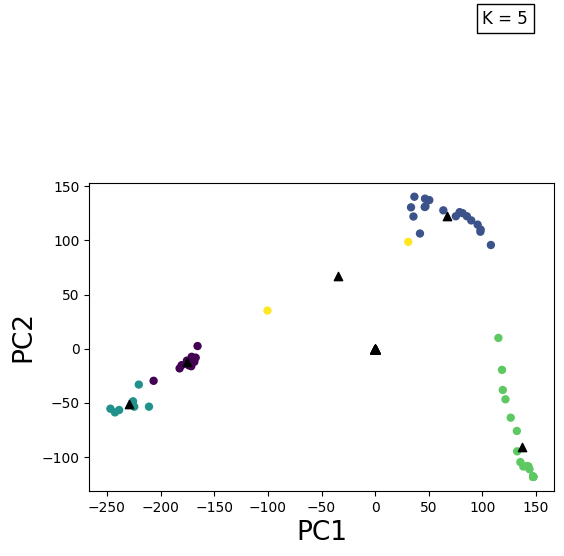

In [12]:
plt.figure(figsize=(6,4))
plt.scatter(df['k5, x'], df['k5, y'], c = df['k5, pred'], s = 25)
plt.scatter(df['k5, centx'].dropna(), df['k5, centy'].dropna(), c = 'black', marker = '^', )
plt.text(100, 300, "K = 5", fontsize=12, bbox=dict(facecolor='white'))
plt.xlabel('PC1', fontdict = {'fontsize' : 19})
plt.ylabel('PC2',  fontdict = {'fontsize' : 19})
plt.savefig('PC1-PC2-K5_graph.png')

plt.show()

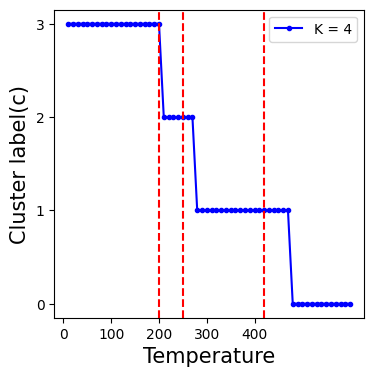

In [35]:
plt.figure(figsize = (4,4))
plt.plot(df['temperature'], df['k4, pred'].sort_values(ascending = False), marker = '.', label = 'K = 4', c = 'blue')
plt.xticks([0, 100, 200, 300, 400])
plt.yticks([0, 1, 2, 3])
plt.xlabel('Temperature', fontdict = {'fontsize' : 15})
plt.ylabel('Cluster label(c)', fontdict = {'fontsize' : 15})
plt.axvline(200, color='red', linestyle='--')
plt.axvline(250, color='red', linestyle='--')
plt.axvline(420, color='red', linestyle='--')
plt.legend(loc = 'upper right')
plt.savefig('Temperature-cluster_label_graph_K4.png')
plt.show()

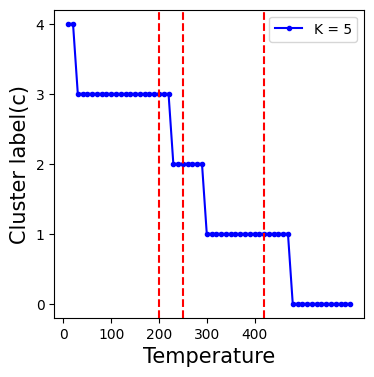

In [34]:
plt.figure(figsize = (4,4))
plt.plot(df['temperature'], df['k5, pred'].sort_values(ascending = False), marker = '.', label = 'K = 5', c = 'blue')
plt.xticks([0, 100, 200, 300, 400])
plt.yticks([0, 1, 2, 3, 4])
plt.xlabel('Temperature', fontdict = {'fontsize' : 15})
plt.ylabel('Cluster label(c)', fontdict = {'fontsize' : 15})
plt.axvline(200, color='red', linestyle='--')
plt.axvline(250, color='red', linestyle='--')
plt.axvline(420, color='red', linestyle='--')
plt.legend(loc = 'upper right')
plt.savefig('Temperature-cluster_label_graph_K5.png')
plt.show()

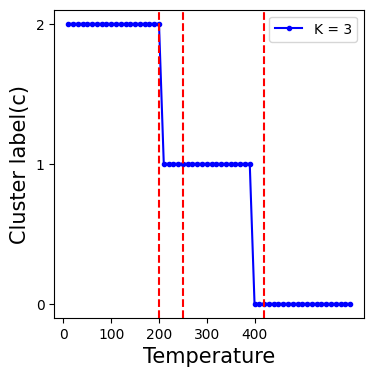

In [33]:

mapping = {2: 2, 0: 1, 1: 0}
df['k3, pred'] = df['k3, pred'].map(mapping)


df_sorted = df.sort_values(by='temperature')


plt.figure(figsize = (4,4))

plt.plot(df_sorted['temperature'],
         df_sorted['k3, pred'],
         marker='.', linestyle='-',
         label='K = 3', c='blue')

plt.xticks([0, 100, 200, 300, 400])
plt.yticks([0, 1, 2])

plt.xlabel('Temperature', fontdict={'fontsize': 15})
plt.ylabel('Cluster label(c)', fontdict={'fontsize': 15})

plt.axvline(200, color='red', linestyle='--')
plt.axvline(250, color='red', linestyle='--')
plt.axvline(420, color='red', linestyle='--')



plt.legend(loc='upper right')

plt.savefig('Temperature-cluster_label_graph_K3.png')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import os

cwd = "C:\\RESEARCH 2\\STRIPE_1k_32\\Stripe_X\\"
file = "StripeX-T-10.plt" #change extension depending on whether file is .plt or .txt

path = f"{cwd}{file}"
if os.path.exists(path): # if input file exists, open and process it
    if file.endswith(".plt"):
        os.rename(path, f"{path[:-4]}.txt")
    path = f"{path[:-4]}.txt"
    print("path \'{}\' exists".format(path))
    fig = plt.figure(figsize=(5,4))
    ax = fig.add_subplot(projection='3d')
    #ax = fig.gca(projection='3d')
    read_file = open(path, "r")
    lines = read_file.readlines()
    x = 0
                    
    # processing lines in old stripe file
    for l in lines:
        flag = 0
        if len(l.split()) > 0:
            if l.split()[1] == "arrow": # if line contains component information
                # print(l.split()[len(l.split())-1])
                last = l.split()[len(l.split())-1]
                n = len(l.split())-1 + len(last.split(','))
                line_data = l.split()[:-1] + last.split(',')
                # print()
                # print(n)
                # print(line_data)
                row = []
                temp = []
                for i in range(n):
                    ass = line_data[i]
                    weenie = ass.split(',')
                    if len(weenie) == 2 and weenie[1] != '':
                        row.append(weenie[0])
                        row.append(weenie[1])
                    else:
                        row.append(weenie[0])
                x_comp = float(row[10]) - float(row[6]) 
                y_comp = float(row[11]) - float(row[7])
                z_comp = float(row[12]) - float(row[8]) 
                temp.append(float(row[6]))
                temp.append(float(row[7]))
                temp.append(float(row[8]))
                temp.append(x_comp)
                temp.append(y_comp)
                temp.append(z_comp)
                                    
                # assigning color value to different x y and z components
                if x_comp > 0 and y_comp > 0 and z_comp > 0: # x y z = + + +
                    temp.append("#FF1493") #pink
                if x_comp > 0 and y_comp > 0 and z_comp < 0: # x y z = + + -
                    temp.append("#CC0000") #red
                if x_comp > 0 and y_comp < 0 and z_comp < 0: # x y z = + - -
                    temp.append("#FF7F50") #orange
                if x_comp > 0 and y_comp < 0 and z_comp > 0: # x y z = + - +
                    temp.append("#FFD700") #yellow   
                if x_comp < 0 and y_comp > 0 and z_comp > 0: # x y z = - + +
                    temp.append("#008000") #green
                if x_comp < 0 and y_comp > 0 and z_comp < 0: # x y z = - + -
                    temp.append("#2ACAEA") #blue  
                if x_comp < 0 and y_comp < 0 and z_comp < 0: # x y z = - - -
                    temp.append("#0000FF") #dark blue
                if x_comp < 0 and y_comp < 0 and z_comp > 0: # x y z = - - +
                    temp.append("#8A2BE2") #purple
                else: #one of the components has a 0 value
                    temp.append("black")
                        
                # plots the respective vector
                ax.quiver([temp[0]], [temp[1]], [temp[2]], [temp[3]], [temp[4]], [temp[5]], colors=[temp[6]], length=1, linewidth=0.5)
                x += 1                    
            
    #change limits according to supercell size
    ax.set_xlim3d([0, 30])
    ax.set_xlabel('X (nm)')
            
    ax.set_ylim3d([0, 30])
    ax.set_ylabel('Y (nm)')
            
    ax.set_zlim3d([0, 30])
    ax.set_zlabel('Z (nm)')
            
    ax.view_init(elev=35, azim=-46)
    # ax.set_axis_off()
            
    #plt.savefig("{}/med_clust_{}.png".format(cwd, file[:-4]), dpi=600)
            
else:
    print("the path \'{}\' does not exist".format(path))




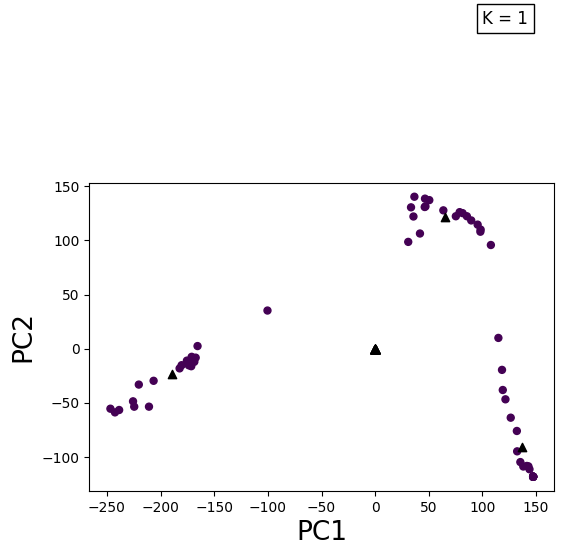

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

stat = pd.read_csv('kmeans_results.csv')
df = pd.DataFrame(stat)

plt.figure(figsize=(6,4))
plt.scatter(df['k1, x'], df['k1, y'], c = df['k1, pred'], s = 25)
plt.scatter(df['k3, centx'], df['k3, centy'], c = 'black', marker = '^' )
plt.text(100, 300, "K = 1", fontsize=12, bbox=dict(facecolor='white'))
plt.xlabel('PC1', fontdict = {'fontsize' : 19})
plt.ylabel('PC2',  fontdict = {'fontsize' : 19})

#plt.savefig('PC1-PC2-K3_graph.png')
plt.show()

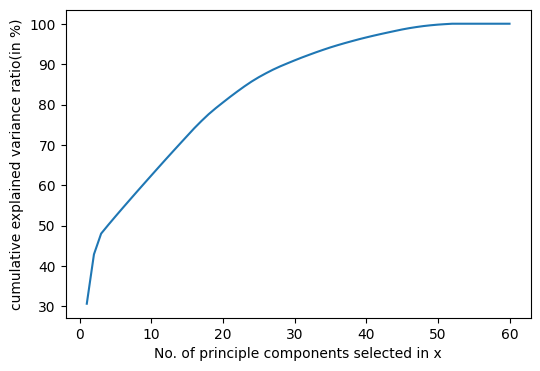

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

stat = pd.read_csv('kmeans_results.csv')
df = pd.DataFrame(stat)

plt.figure(figsize=(6,4))
plt.plot(df['PCA-x'], df['PCA-y'])
#plt.scatter(df['k3, centx'], df['k3, centy'], c = 'black', marker = '^' )
#plt.text(100, 300, "K = 3", fontsize=12, bbox=dict(facecolor='white'))
plt.xlabel('No. of principle components selected in x', fontdict = {'fontsize' : 10})
plt.ylabel('cumulative explained variance ratio(in %)',  fontdict = {'fontsize' : 10})

plt.savefig('variance ratio as a function of principle components in x.png')
plt.show()